**Goal:**
This study aims to analyze the interannual impacts of the El Niño–Southern Oscillation (ENSO) on tropical terrestrial carbon flux (GPP), with a particular focus on whether geoengineering can effectively reduce the negative sensitivity of land carbon uptake under future high CO₂ conditions.
We investigate how tropical terrestrial carbon flux (within 40°S–40°N) responds to ENSO events across three climate scenarios—preindustrial, high-CO₂ warming, and SRM (solar radiation management)—and further explore the possible causes behind these differences.

**Data used:**
The data used in this project come from the Canadian Earth System Model (CanESM5) within the Coupled Model Intercomparison Project Phase 6 (CMIP6).
Three standard climate scenarios were analyzed:
1.**piControl** (preindustrial control scenario): Represents the natural climate state before the Industrial Revolution, with constant CO₂ concentration.
2.**abrupt-4×CO₂ **(high-CO₂ warming scenario): Atmospheric CO₂ concentration is instantaneously increased to four times the preindustrial level and then held constant, representing strong global warming under sustained high CO₂ conditions.
3.**G1** (SRM cooling scenario): Based on the 4×CO₂ setting, incoming solar radiation is artificially reduced to bring global mean temperature back to preindustrial levels, representing a form of geoengineering known as Solar Radiation Management (SRM).
The model simulations cover about 50 years (approximately 1890–1949). All data were regridded to a uniform 1°×1° spatial resolution, focusing on the tropical land region (40°S–40°N).

**The planned analysis:**
1.**ENSO index calculation and visualization.**
Calculate the standardized ENSO index (DJF Niño3.4 sea surface temperature anomaly) and plot its interannual time series to compare ENSO intensity and frequency under the three climate scenarios.
2.**Visualization of tropical GPP interannual variations.**
Plot the annual variations of tropical terrestrial carbon flux (GPP) for the three scenarios to visually show the differences in interannual fluctuations.
3.**Calculation and comparison of GPP sensitivity to ENSO.**
Quantify and visualize the sensitivity of tropical GPP to ENSO events (using linear regression coefficients) and perform statistical significance tests to highlight differences among the three scenarios.
4.**Spatial distribution analysis of sensitivity.**
Map the spatial distribution of GPP sensitivity to ENSO to reveal which regions are most affected under each scenario.
5.**Attribution analysis.**
Further analyze the contributions of temperature and precipitation changes to variations in GPP sensitivity, aiming to understand the underlying mechanisms driving the ENSO–GPP relationship in the SRM scenario.

**Import libraries**


In [93]:
import sys
print(sys.executable)
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import cartopy.crs as ccrs
from matplotlib import gridspec

D:\miniconda\envs\research\python.exe


**step.1 Read data files**

First, we read and checked the NetCDF dThe latitude and longitude variable names differ among files, so they need to be automatically detectedata files, including latitude/longitude coordinates and time range, to ensure the accuracy of subsequent analysis.

In [94]:
# Set path
data_dir = Path(r'D:\cangku\data')

# List of NetCDF files to analyze
files = [
    #gpp（abrupt-4xCO2，G1，piControl）
    'gpp_Lmon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012.nc',
    'gpp_Lmon_CanESM5_G1_r1i1p2f1_gn_185001-194912.nc',
    'gpp_Lmon_CanESM5_piControl_r1i1p2f1_gn_185001-194912.nc',
    #tos（abrupt-4xCO2，G1，piControl）
    "tos_Omon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012.nc",
    "tos_Omon_CanESM5_G1_r1i1p2f1_gn_185001-194912.nc",
    "tos_Omon_CanESM5_piControl_r1i1p2f1_gn_185001-194912.nc",
    #tas（abrupt-4xCO2，G1，piControl）
    'tas_Amon_CanESM5_abrupt-4xCO2_185001-200012.nc',     
    'tas_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912.nc',
    #pr（abrupt-4xCO2，G1，piControl）
    'pr_Amon_CanESM5_abrupt-4xCO2_185001-200012.nc',   
    'pr_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912.nc',
]

In [95]:
# The latitude and longitude variable names differ among files, so they need to be automatically detected
def find_lat_lon_names(ds):
    lat_name, lon_name = None, None
    for candidate in ['lat', 'latitude', 'nav_lat', 'y']:
        if candidate in ds.variables:
            lat_name = candidate
            break
    for candidate in ['lon', 'longitude', 'nav_lon', 'x']:
        if candidate in ds.variables:
            lon_name = candidate
            break
    if lat_name is None or lon_name is None:
        raise ValueError('Failed to automatically identify latitude and longitude variable names')
    return lat_name, lon_name

In [98]:
# Check each file and print a short summary
def summarize_dataset(file_path):
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    with xr.open_dataset(file_path, decode_times=time_coder) as ds:
        lat_name, lon_name = find_lat_lon_names(ds)    # Read different latitude and longitude names
       
        lat = ds[lat_name]
        lon = ds[lon_name]
        time = ds['time']

        print(f'File: {file_path.name}')
        print(f'  Latitude dimensions: {lat.shape}')
        print(f'  Longitude dimensions: {lon.shape}')
        print(f'  Time dimension length: {time.size}')
        print(f'  Time range: {str(time.values[0])} to {str(time.values[-1])}')
                
for filename in files:
    path = data_dir / filename
    if path.exists():
        try:
            summarize_dataset(path)
        except Exception:
            print(f'Failed to read {filename}. Please verify the file content.')
    else:
        print(f'{filename} not found in the data directory.')
        

File: gpp_Lmon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012.nc
  Latitude dimensions: (64,)
  Longitude dimensions: (128,)
  Time dimension length: 1812
  Time range: 1850-01-16 12:00:00 to 2000-12-16 12:00:00
File: gpp_Lmon_CanESM5_G1_r1i1p2f1_gn_185001-194912.nc
  Latitude dimensions: (64,)
  Longitude dimensions: (128,)
  Time dimension length: 1200
  Time range: 1850-01-16 12:00:00 to 1949-12-16 12:00:00
File: gpp_Lmon_CanESM5_piControl_r1i1p2f1_gn_185001-194912.nc
  Latitude dimensions: (64,)
  Longitude dimensions: (128,)
  Time dimension length: 1200
  Time range: 1850-01-15 00:00:00 to 1949-12-15 00:00:00
File: tos_Omon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012.nc
  Latitude dimensions: (291, 360)
  Longitude dimensions: (291, 360)
  Time dimension length: 1812
  Time range: 1850-01-16 12:00:00 to 2000-12-16 12:00:00
File: tos_Omon_CanESM5_G1_r1i1p2f1_gn_185001-194912.nc
  Latitude dimensions: (291, 360)
  Longitude dimensions: (291, 360)
  Time dimension length: 1200
  

**step.2 Data processing **

2.1 Interpolation (unifying spatial resolution)

In [ ]:
Since the spatial resolutions of model outputs vary, all data were interpolated to a standard 1°×1° grid.

In [5]:
# Define interpolation grid (1° × 1°)
lon_target = np.arange(0, 360, 1) #The original longitude is 180°W–180°E, convert to 0–360 for easier calculation
lat_target = np.arange(-90, 90, 1)

In [99]:
#Ensure all datasets have consistent latitude/longitude naming and coordinate systems

def fix_lon(lon):
    return lon % 360  #Convert longitude to the 0–360 range

def standardize_coords(ds):
    # Standardize latitude and longitude variable names
    for lat_name in ['lat', 'latitude', 'nav_lat', 'y']:
        if lat_name in ds:
            ds = ds.rename({lat_name: 'lat'})
            break
    for lon_name in ['lon', 'longitude', 'nav_lon', 'x']:
        if lon_name in ds:
            ds = ds.rename({lon_name: 'lon'})
            break

    # tos data have 2D lat/lon, need to simplify to 1D
    if ds['lon'].ndim == 2 and ds['lat'].ndim == 2:
        lat_1d = ds['lat'][:, 0].values
        lon_1d = ds['lon'][0, :].values
        lon_1d = fix_lon(lon_1d)
        ds = ds.drop_vars(['lon', 'lat'], errors='ignore')
        ds = ds.rename({'j': 'lat', 'i': 'lon'})
        ds = ds.assign_coords(lon=lon_1d, lat=lat_1d)

    ds['lon'] = fix_lon(ds['lon'])
    return ds.sortby('lon')

In [7]:
#Define function for interpolating a single file
def regrid(file):
    with xr.open_dataset(file) as ds:
        var = file.name.split('_')[0]
        if var not in ds:
            var = list(ds.data_vars)[0] 

        ds = ds[[var, 'time']]
        ds = standardize_coords(ds)

        ds_interp = ds.interp(lon=lon_target, lat=lat_target, method='linear') #Use linear interpolation to unify resolution

        out_file = file.with_name(file.stem + '_1x1.nc')
        ds_interp.to_netcdf(out_file)  

        print(f'Finished: {out_file.name}')
        
#Execute interpolation
for f in files:
    file_path = data_dir / f
    if file_path.exists():
        try:
            regrid(file_path)
        except Exception as e:
            print(f'Error: {f}, {e}') 
    else:
        print(f'File not found: {f}')

Finished: gpp_Lmon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012_1x1.nc
Finished: gpp_Lmon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1.nc
Finished: gpp_Lmon_CanESM5_piControl_r1i1p2f1_gn_185001-194912_1x1.nc
Finished: tos_Omon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012_1x1.nc
Finished: tos_Omon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1.nc
Finished: tos_Omon_CanESM5_piControl_r1i1p2f1_gn_185001-194912_1x1.nc
Finished: tas_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1.nc
Finished: tas_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1.nc
Finished: pr_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1.nc
Finished: pr_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1.nc


**2.2 Detrend**

We performed detrending on the data to remove the effects of long-term external forcing (such as rising CO₂ or different model configurations) and to highlight the true response of terrestrial carbon fluxes to ENSO-related interannual climate variability.

In [7]:
input_files = [
    'gpp_Lmon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012_1x1.nc',
    'gpp_Lmon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1.nc',
    'gpp_Lmon_CanESM5_piControl_r1i1p2f1_gn_185001-194912_1x1.nc',
    'tos_Omon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012_1x1.nc',
    'tos_Omon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1.nc',
    'tos_Omon_CanESM5_piControl_r1i1p2f1_gn_185001-194912_1x1.nc',
    'tas_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1.nc',
    'tas_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1.nc',
    'pr_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1.nc',
    'pr_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1.nc',
]

In [8]:
#Define detrending function
def detrend(data):
    t, nlat, nlon = data.shape
    time_index = np.arange(t)
    out = np.full_like(data, np.nan)

    for i in range(nlat):
        for j in range(nlon):
            y = data[:, i, j]
            if np.isfinite(y).sum() < 2:
                continue
            p = np.polyfit(time_index, y, 1) #Least squares method
            out[:, i, j] = y - np.polyval(p, time_index)
    return out

def process_one(path):
    with xr.open_dataset(path) as ds:
        var = next((v for v in ['gpp', 'tos', 'tas', 'pr'] if v in ds), None)
        if not var:
            print(f'Skipped {path.name}, main variable not found.')
            return
        da = ds[var].sel(time=slice('1890-01', '1949-12')).astype('float64') # Detrending period: 1890–1949
        detrended = detrend(da.values)

        da_dt = xr.DataArray(
            detrended, coords=da.coords, dims=da.dims, name=var, attrs=da.attrs
        )

        out_path = path.with_name(path.stem + '_1890-1949_detrend.nc')
        da_dt.to_netcdf(out_path)
        print(f'Finished: {out_path.name}')

# Batch detrending
for fname in input_files:
    path = data_dir / fname
    if path.exists():
        try:
            process_one(path)
        except Exception as e:
            print(f'Error processing {fname}: {e}')
    else:
        print(f'File not found: {fname}')

Finished: gpp_Lmon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012_1x1_1890-1949_detrend.nc
Finished: gpp_Lmon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc
Finished: gpp_Lmon_CanESM5_piControl_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc
Finished: tos_Omon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012_1x1_1890-1949_detrend.nc
Finished: tos_Omon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc
Finished: tos_Omon_CanESM5_piControl_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc
Finished: tas_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1_1890-1949_detrend.nc
Finished: tas_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc
Finished: pr_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1_1890-1949_detrend.nc
Finished: pr_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc


**step.3 ENSO Index Calculation and Visualization**

In [58]:

DATA_DIR = Path(r"D:\cangku\data")

FILES = {
    "abrupt-4xCO2": "tos_Omon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012_1x1_1890-1949_detrend.nc",
    "G1": "tos_Omon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc",
    "piControl": "tos_Omon_CanESM5_piControl_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc",
}

(1) Calculation of the ENSO Index:
We used the standardized anomaly of the December–February (DJF) mean sea surface temperature (SST) over the Niño3.4 region (5°N–5°S, 170°W–120°W) as the ENSO indicator.
The Niño3.4 region best captures the core strength of ENSO events, while DJF represents the season when the ENSO signal is most mature and its climatic impacts are strongest. The standardization ensures comparability across different years and models.

a. We extracted SST (tos) from the equatorial central–eastern Pacific Niño3.4 region (latitude 5°N–5°S, longitude 170°W–120°W).
b. We computed the area-averaged SST for each December–February season, then removed the long-term climatological mean to obtain the DJF SST anomalies for each year.
c. These anomalies were standardized (subtracting the mean and dividing by the standard deviation) to derive the final standardized Niño3.4 index.

A positive Niño3.4 index indicates an El Niño event (warming in the central–eastern Pacific), while a negative value represents a La Niña event (cooling anomaly).
The larger the absolute value, the stronger the event. This method allows for an accurate and objective assessment of the relative strength and variability of each ENSO episode.

In [59]:
# Define Niño3.4 region boundaries
lat_bounds = (-5, 5)    #5°N–5°S
lon_bounds = (190, 240) #170°W–120°W

# Define function to calculate ENSO index
def calc_djf_index(ds):
    tos = ds['tos']
    tos_sel = tos.sel(lat=slice(*lat_bounds), lon=slice(*lon_bounds))
    tos_mean = tos_sel.mean(dim=('lat', 'lon'))

    # DJF season mean
    djf = tos_mean.rolling(time=3, center=True).mean()
    djf = djf.sel(time=djf['time.month'] == 1)
    djf = djf.sel(time=slice('1890-01-01', '1949-12-31'))

    values = djf.values
    #values = (values - np.nanmean(values)) / np.nanstd(values) # Standardize ENSO index
    values = (values - np.nanmean(values))
    return values, djf['time'].dt.year.values

ENSO_index = np.zeros((3, 60)) #Store ENSO indices for three scenarios
years = None
for k, fname in enumerate(FILES.values()):
    ds = xr.open_dataset(DATA_DIR / fname)
    values, yrs = calc_djf_index(ds)
    ENSO_index[k, :] = values
    if years is None:
        years = yrs
    ds.close()

print('ENSO_index shape:', ENSO_index.shape)

ENSO_index shape: (3, 60)


(2) Plotting the Year-to-Year Variability of the ENSO Index
We visualized the annual fluctuations of the ENSO index to compare the event intensities among the three scenarios—abrupt-4xCO₂, G1, and piControl.
This provides a clear background for understanding how ENSO modulates the sensitivity of terrestrial carbon fluxes (GPP) in tropical regions under different forcing conditions.

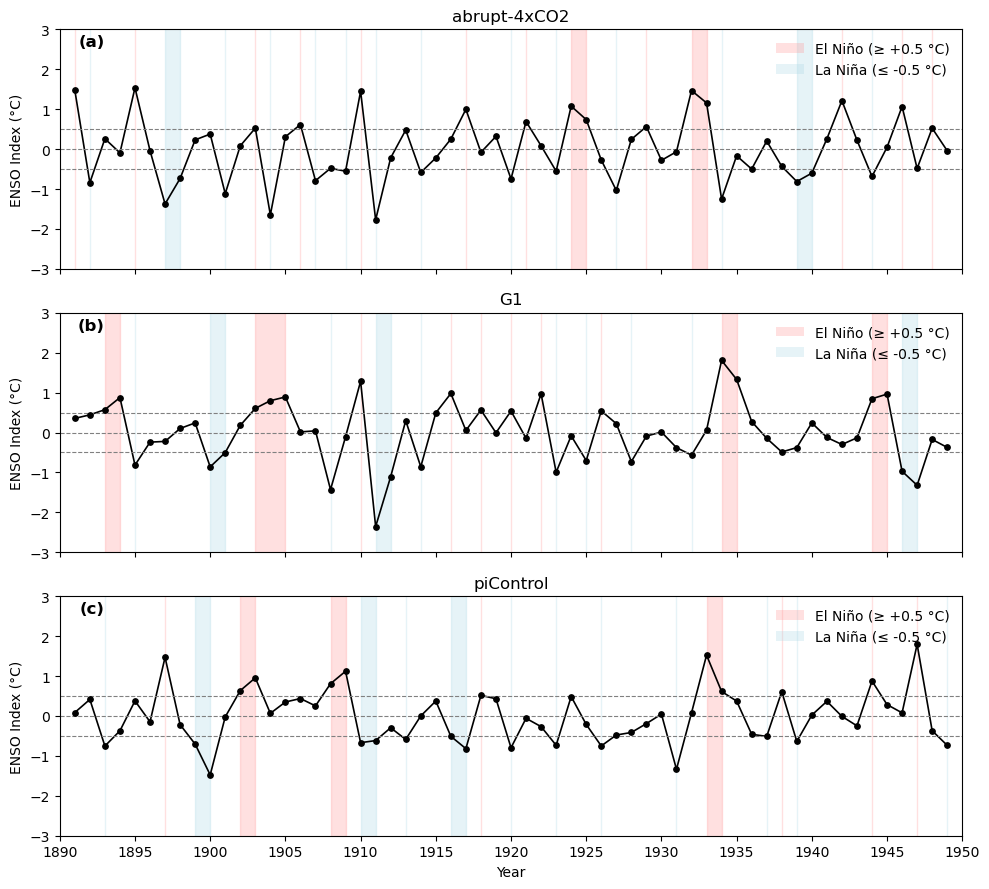

In [63]:
# draw picture
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for i, (exp, fname) in enumerate(FILES.items()):
    ax = axes[i]
    vals = ENSO_index[i, :]
    
    ax.fill_between(years, -5, 5, where=vals > 0.5, color='#FF9999', alpha=0.3)  # ENSO index ≥ +0.5 → El Niño (warm phase)
    ax.fill_between(years, -5, 5, where=vals < -0.5, color='#ADD8E6', alpha=0.3) # ENSO index ≤ -0.5 → La Niña (cold phase)
    ax.plot(years, vals, color='black', linewidth=1.2)
    ax.scatter(years, vals, color='black', s=15, zorder=3)

    # y = 0 represents climatological equilibrium; ±0.5 marks ENSO thresholds
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axhline(0.5, color='gray', linewidth=0.8, linestyle='--')
    ax.axhline(-0.5, color='gray', linewidth=0.8, linestyle='--')

    ax.set_ylim(-3, 3)
    ax.set_ylabel('ENSO Index (°C)')
    ax.set_title(exp)
    
    ax.text(0.05, 0.98, f'({chr(97+i)})', transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top', ha='right')
    # legend
    legend_handles = [
        Patch(facecolor='#FF9999', alpha=0.3, label='El Niño (≥ +0.5 °C)'),
        Patch(facecolor='#ADD8E6', alpha=0.3, label='La Niña (≤ -0.5 °C)')
    ]
    ax.legend(handles=legend_handles, loc='upper right', frameon=False)

axes[-1].set_xlabel('Year')
axes[-1].set_xlim(1890, 1950)
axes[-1].set_xticks(np.arange(1890, 1951, 5))

plt.tight_layout()

plt.savefig('DJF_Nino34_1890-1949.png', dpi=300, bbox_inches='tight')
plt.show()

**step.4 Interannual Variations of Tropical Terrestrial Carbon Flux (GPP)**

We plotted the interannual variability of terrestrial carbon flux (GPP) in the tropical region (40°S–40°N) to illustrate the year-to-year trends under different climate scenarios (piControl, abrupt-4xCO₂, G1).
This comparison highlights both the short-term fluctuations and long-term trends of tropical GPP, providing essential context for further investigating how ENSO influences GPP responses.

Land Area Corresponding to Each 1°×1° Grid Cell
We matched the land area data to the GPP grid to ensure their latitude–longitude coordinates are perfectly aligned.

In [12]:
DATA_DIR = Path(r'D:\cangku\data')

GPP_FILES = {
    'abrupt-4xCO2': 'gpp_Lmon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012_1x1_1890-1949_detrend.nc',
    'G1': 'gpp_Lmon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc',
    'piControl': 'gpp_Lmon_CanESM5_piControl_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc',
}

AREA_FILE = DATA_DIR / 'landarea_1x1.nc'   #matched the land area data to the GPP grid to ensure their latitude–longitude coordinates are perfectly aligned.
LAT_SLICE = slice(-40, 40)

In [13]:
# Match land area data to the GPP grid so that both share identical lat/lon coordinates
def standardize_coords(ds):
    if 'latitude' in ds.coords: ds = ds.rename({'latitude': 'lat'})
    if 'longitude' in ds.coords: ds = ds.rename({'longitude': 'lon'})
    if 'lon' in ds.coords and float(ds['lon'].min()) < 0:
        ds = ds.assign_coords(lon=(ds['lon'] % 360)).sortby('lon')
    return ds

# Build area data on the same grid as GPP
def build_area_on_gpp_grid(area_path, gpp_ref_da):
    ds_area = xr.open_dataset(area_path)
    if 'area' not in ds_area.data_vars:
        if len(ds_area.data_vars) == 1:
            only = list(ds_area.data_vars)[0]
            ds_area = ds_area.rename({only: 'area'})
        else:
            raise KeyError('fsil find vars \'area\'')
    ds_area = standardize_coords(ds_area)
    area = ds_area['area'].sel(lat=LAT_SLICE)
    area_matched = area.interp(lat=gpp_ref_da.lat, lon=gpp_ref_da.lon, method='nearest') # Use nearest-neighbor interpolation to match area data to GPP grid
    return area_matched.broadcast_like(gpp_ref_da.isel(time=0))

Calculation of Annual Total GPP in the Tropical Region

We first calculated the total carbon uptake for each month and each grid cell based on the grid-level GPP rate (unit: kg C m⁻² s⁻¹).

Step 1: Multiply the GPP rate (kg C m⁻² s⁻¹) by the corresponding land area of each grid cell (km², converted to m² by multiplying 10⁶), and then by the total number of seconds in that month (days × 86400). This yields the monthly total carbon uptake (kg C) for each grid cell.

Step 2: Sum the results across all grid cells to obtain the regional total carbon uptake (kg C) for each month. To better represent large-scale carbon fluxes, the unit is converted from kilograms to petagrams of carbon (PgC, where 1 PgC = 10¹² kg C) by multiplying by 10⁻¹².

Step 3: Finally, sum up all twelve monthly totals to obtain the annual total carbon uptake (PgC yr⁻¹) for the entire tropical region (40°S–40°N).

In [14]:
# Calculate total annual GPP flux (PgC/yr) for the study region (40°S–40°N)
def compute_annual_gpp_total(gpp_path, area_matched):
    ds = xr.open_dataset(gpp_path)
    ds = standardize_coords(ds)
    if 'gpp' not in ds.data_vars:
        only = list(ds.data_vars)[0]
        ds = ds.rename({only: 'gpp'})
    gpp = ds['gpp'].sel(lat=LAT_SLICE)

    area_use = area_matched.sel(lat=gpp.lat, lon=gpp.lon)
    area_use = xr.where(gpp.isel(time=0).isnull(), 0.0, area_use)
    days_in_month = gpp['time'].dt.days_in_month
    monthly_total = (gpp * area_use * days_in_month * 86400).sum(('lat','lon')) * 1e-12 * 1e6 # unit conversion to PgC
    annual_total = monthly_total.resample(time='YS').sum().sel(time=slice('1890','1949'))
    return annual_total



gpp_ref = xr.open_dataset(DATA_DIR / GPP_FILES['piControl'])['gpp']
area_ref = build_area_on_gpp_grid(AREA_FILE, gpp_ref)

GPP_totals = {}
for exp, fname in GPP_FILES.items():
    ann = compute_annual_gpp_total(DATA_DIR / fname, area_ref)
    GPP_totals[exp] = ann.values  # PgC/yr
years = ann['time.year'].values  # total of 60 years

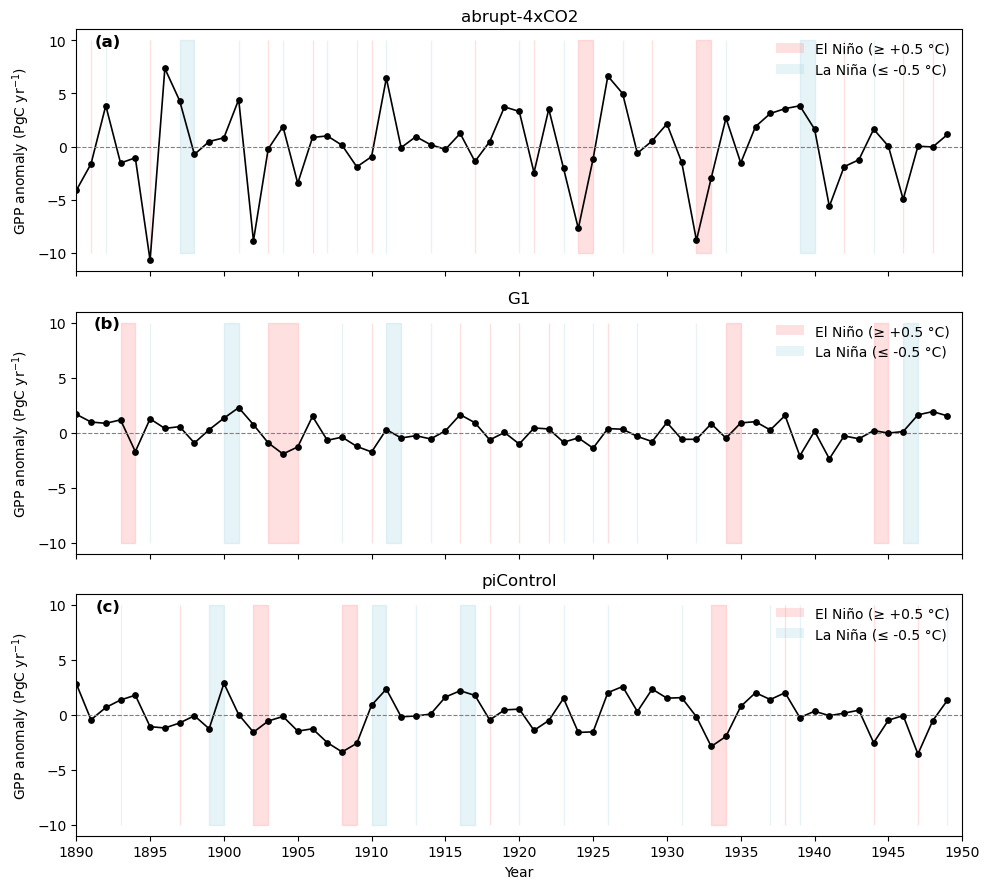

In [64]:
# draw picture
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for i, (exp, gpp_vals) in enumerate(GPP_totals.items()):
    ax = axes[i]
    enso_vals = ENSO_index[i, :]   
    ax.fill_between(years, -10, 10, where=enso_vals >= 0.5, color='#FF9999', alpha=0.3)
    ax.fill_between(years, -10, 10, where=enso_vals <= -0.5, color='#ADD8E6', alpha=0.3)

    ax.plot(years, gpp_vals, color='black', linewidth=1.2)
    ax.scatter(years, gpp_vals, color='black', s=15, zorder=3)
    
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_ylabel('GPP anomaly (PgC yr$^{-1}$)')
    ax.set_title(exp)
    ax.text(0.05, 0.98, f'({chr(97+i)})', transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top', ha='right')

    legend_handles = [
        Patch(facecolor='#FF9999', alpha=0.3, label='El Niño (≥ +0.5 °C)'),
        Patch(facecolor='#ADD8E6', alpha=0.3, label='La Niña (≤ -0.5 °C)')
    ]
    ax.legend(handles=legend_handles, loc='upper right', frameon=False)

axes[-1].set_xlabel('Year')
axes[-1].set_xlim(1890, 1950)
axes[-1].set_xticks(np.arange(1890, 1951, 5))

plt.tight_layout()

plt.savefig('GPP_anomalies_40S40N_1890-1949.png', dpi=300, bbox_inches='tight')
plt.show()


**step.5. Sensitivity Analysis of Tropical Carbon Flux to ENSO**

We quantitatively assessed how tropical terrestrial carbon flux (GPP) responds to ENSO variability under different climate scenarios by computing regression coefficients between the GPP anomalies and the ENSO index.


In [ ]:
Bar charts were then plotted to clearly display the differences and statistical significance among the three experiments (abrupt-4xCO₂, G1, and piControl).

This analysis allows us to explicitly identify how the strength of ENSO’s impact on land carbon uptake differs across various climate forcing conditions.

In [ ]:
# ENSO_index: shape (3, 60) – ENSO indices for the three scenarios
# GPP_totals: dict – interannual GPP variations (PgC/yr) for the three scenarios


exp_names = ['abrupt-4xCO2', 'G1', 'piControl']
GPP_array = np.vstack([GPP_totals[exp] for exp in exp_names])  # Convert GPP_totals into an array with shape (3, 60)

In [68]:
# Define function to calculate regression coefficient
def calc_regression_coef(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() > 1:
        return np.cov(x[mask], y[mask], ddof=1)[0, 1] / np.var(x[mask], ddof=1)
    else:
        return np.nan

#  Bootstrap confidence interval estimation 
n_boot = 5000
rng = np.random.default_rng(seed=42)

# Compute regression coefficients and confidence intervals for each scenario
betas = []
ci_lows = []
ci_highs = []

for i in range(3):
    x = ENSO_index[i, :]
    y = GPP_array[i, :]
    
    # Calculate regression coefficient (sensitivity)
    beta = calc_regression_coef(x, y)
    betas.append(beta)
    
    # Bootstrap resampling to estimate 95% confidence interval
    mask = np.isfinite(x) & np.isfinite(y)
    x_valid, y_valid = x[mask], y[mask]
    n = len(x_valid)
    
    boot_betas = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        boot_betas.append(calc_regression_coef(x_valid[idx], y_valid[idx]))
    
    ci_low, ci_high = np.percentile(boot_betas, [2.5, 97.5])
    ci_lows.append(ci_low)
    ci_highs.append(ci_high)

betas = np.array(betas)
yerr = np.vstack([betas - np.array(ci_lows), np.array(ci_highs) - betas])
print(betas)

[-2.91213562 -0.18242003 -1.60514598]


In [ ]:
# Estimating Sensitivity Differences Between Scenarios
pairs = [
    ("abrupt-4xCO2", "piControl"),
    ("G1", "abrupt-4xCO2"),  
    ("G1", "piControl")
]

pair_labels = [f"{a} – {b}" for a, b in pairs]
diff_means = []
diff_err_low = []
diff_err_high = []

for expA, expB in pairs:
    iA = exp_names.index(expA)
    iB = exp_names.index(expB)
    
    xA, yA = ENSO_index[iA, :], GPP_array[iA, :]
    xB, yB = ENSO_index[iB, :], GPP_array[iB, :]
    
    # differences in ENSO–GPP sensitivity among the three climate experiments using bootstrap resampling.
    maskA = np.isfinite(xA) & np.isfinite(yA)
    maskB = np.isfinite(xB) & np.isfinite(yB)
    xA_v, yA_v = xA[maskA], yA[maskA]
    xB_v, yB_v = xB[maskB], yB[maskB]
    
    boot_diffs = []
    for _ in range(n_boot):
        idxA = rng.integers(0, len(xA_v), len(xA_v))
        idxB = rng.integers(0, len(xB_v), len(xB_v))
        betaA = calc_regression_coef(xA_v[idxA], yA_v[idxA])
        betaB = calc_regression_coef(xB_v[idxB], yB_v[idxB])
        boot_diffs.append(betaA - betaB)
    
    mean_diff = np.nanmean(boot_diffs)
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
    
    diff_means.append(mean_diff)
    diff_err_low.append(mean_diff - ci_low)
    diff_err_high.append(ci_high - mean_diff)

diff_yerr = np.vstack([diff_err_low, diff_err_high])

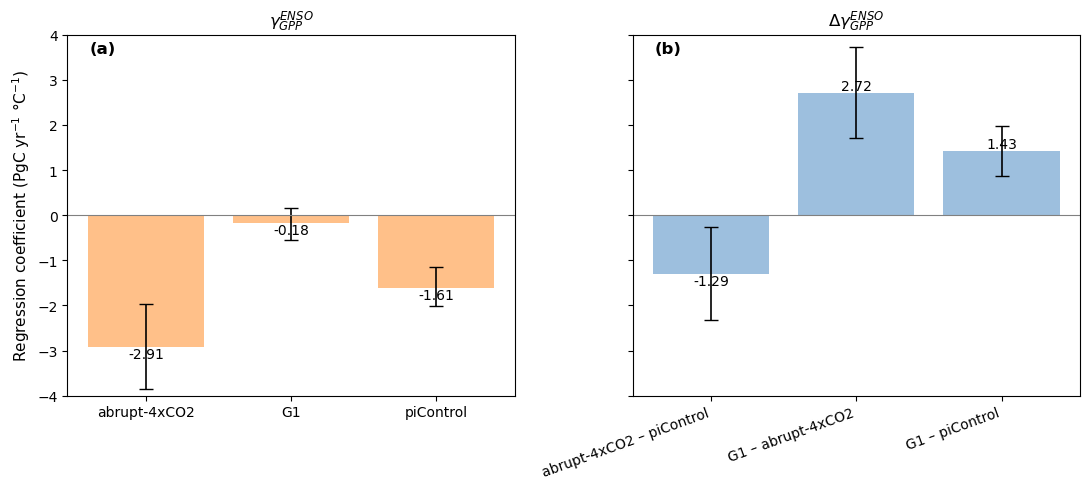

In [71]:
# plot
colors_coeff = ['#FFB574', '#FFB574', '#FFB574']  # light orange for regression coefficients
colors_diff = ['#8CB4D9', '#8CB4D9', '#8CB4D9']   #  light blue for sensitivity differences


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

# (a): Regression Coefficients Across Scenarios
bars1 = ax1.bar(exp_names, betas, yerr=yerr,
                color=colors_coeff, alpha=0.85, capsize=5, 
                error_kw=dict(lw=1.2))

for bar, val in zip(bars1, betas):
    ax1.text(bar.get_x() + bar.get_width()/2, val,
             f'{val:.2f}', ha='center', 
             va='bottom' if val >= 0 else 'top', fontsize=10)

ax1.axhline(0, color='gray', lw=0.8)
ax1.set_title(r'$\gamma_{GPP}^{ENSO}$', fontsize=12)
ax1.set_ylabel('Regression coefficient (PgC yr$^{-1}$ °C$^{-1}$)', fontsize=11)
ax1.set_ylim(-4, 4)
ax1.text(0.05, 0.95, '(a)', transform=ax1.transAxes, 
         fontsize=12, fontweight='bold')

# (b): Differences in Regression Coefficients Between Scenarios
bars2 = ax2.bar(range(len(pair_labels)), diff_means, yerr=diff_yerr,
                color=colors_diff, alpha=0.85, capsize=5,
                error_kw=dict(lw=1.2))

for bar, val in zip(bars2, diff_means):
    ax2.text(bar.get_x() + bar.get_width()/2, val,
             f'{val:.2f}', ha='center',
             va='bottom' if val >= 0 else 'top', fontsize=10)

ax2.axhline(0, color='gray', lw=0.8)
ax2.set_title(r'$\Delta \gamma_{GPP}^{ENSO}$', fontsize=12)
ax2.set_xticks(range(len(pair_labels)))
ax2.set_xticklabels(pair_labels, rotation=20, ha='right')
ax2.text(0.05, 0.95, '(b)', transform=ax2.transAxes,
         fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('GPP_ENSO_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

**step.6 Spatial Sensitivity Analysis**

In [ ]:
Finally, we mapped the spatial distribution of GPP sensitivity to ENSO to visualize how different tropical regions respond under varying climate conditions.
This spatial perspective helps clarify regional contrasts in ENSO responses and highlights potential ecological impacts under geoengineering scenarios.

In [80]:
DATA_DIR = Path(r'D:\cangku\data')
GPP_FILES = {
    'abrupt-4xCO2': 'gpp_Lmon_CanESM5_abrupt-4xCO2_r1i1p2f1_gn_185001-200012_1x1_1890-1949_detrend.nc',
    'G1': 'gpp_Lmon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc',
    'piControl': 'gpp_Lmon_CanESM5_piControl_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc',
}
LAT_SLICE = slice(-40, 40)

In [81]:
# Calculate spatial regression coefficients
# Each grid cell represents the local GPP–ENSO sensitivity (slope of regression).

# def standardize_coords(ds):
#     """Standardize coordinate names"""
#     if 'latitude' in ds.coords:  
#         ds = ds.rename({'latitude': 'lat'})
#     if 'longitude' in ds.coords: 
#         ds = ds.rename({'longitude': 'lon'})
#     if 'lon' in ds.coords and float(ds['lon'].min()) < 0:
#         ds = ds.assign_coords(lon=(ds['lon'] % 360)).sortby('lon')
#     return ds


#  Compute annual cumulative GPP for each grid cell 

def compute_annual_gpp_field(gpp_path):

    ds = xr.open_dataset(gpp_path)
    ds = standardize_coords(ds)
    var = 'gpp' if 'gpp' in ds.data_vars else list(ds.data_vars)[0]
    gpp = ds[var].sel(lat=LAT_SLICE)
    
    days = gpp['time'].dt.days_in_month
    gpp_annual = (gpp * days * 86400).resample(time='YS').sum()
    gpp_annual = gpp_annual.sel(time=slice('1890','1949'))
    
    return gpp_annual.astype('float32')

# Define and Visualize Spatial Sensitivity of GPP to ENSO
def calc_spatial_regression(gpp_annual_da, enso_series):
    gpp = gpp_annual_da.values
    t, nlat, nlon = gpp.shape
    betas = np.full((nlat, nlon), np.nan, dtype='float32')
    
    for i in range(nlat):
        for j in range(nlon):
            y = gpp[:, i, j]
            if np.all(np.isnan(y)): 
                continue
            
            mask = np.isfinite(enso_series) & np.isfinite(y)
            if mask.sum() > 1:
                betas[i, j] = np.cov(enso_series[mask], y[mask], ddof=1)[0, 1] / np.var(enso_series[mask], ddof=1)
    
    return betas


GPP_annual = {}
for exp, fname in GPP_FILES.items():
    da = compute_annual_gpp_field(DATA_DIR / fname)
    print(f'{exp}: shape={da.shape}')
    GPP_annual[exp] = da
    
# Calculate spatial regression coefficients
exp_order = ['abrupt-4xCO2', 'G1', 'piControl']
beta_maps = {}

for i, exp in enumerate(exp_order):
    betas = calc_spatial_regression(GPP_annual[exp], ENSO_index[i, :])
    beta_maps[exp] = betas
    print(f'{exp} beta range: [{np.nanmin(betas):.3f}, {np.nanmax(betas):.3f}]')

# Calculate differences
diff_maps = {
    'abrupt-4xCO2 − piControl': beta_maps['abrupt-4xCO2'] - beta_maps['piControl'],
    'G1 − abrupt-4xCO2': beta_maps['G1'] - beta_maps['abrupt-4xCO2'],
    'G1 − piControl': beta_maps['G1'] - beta_maps['piControl']
}


abrupt-4xCO2: shape=(60, 81, 360)
G1: shape=(60, 81, 360)
piControl: shape=(60, 81, 360)
abrupt-4xCO2 beta range: [-0.385, 0.182]
G1 beta range: [-0.216, 0.352]
piControl beta range: [-0.248, 0.326]


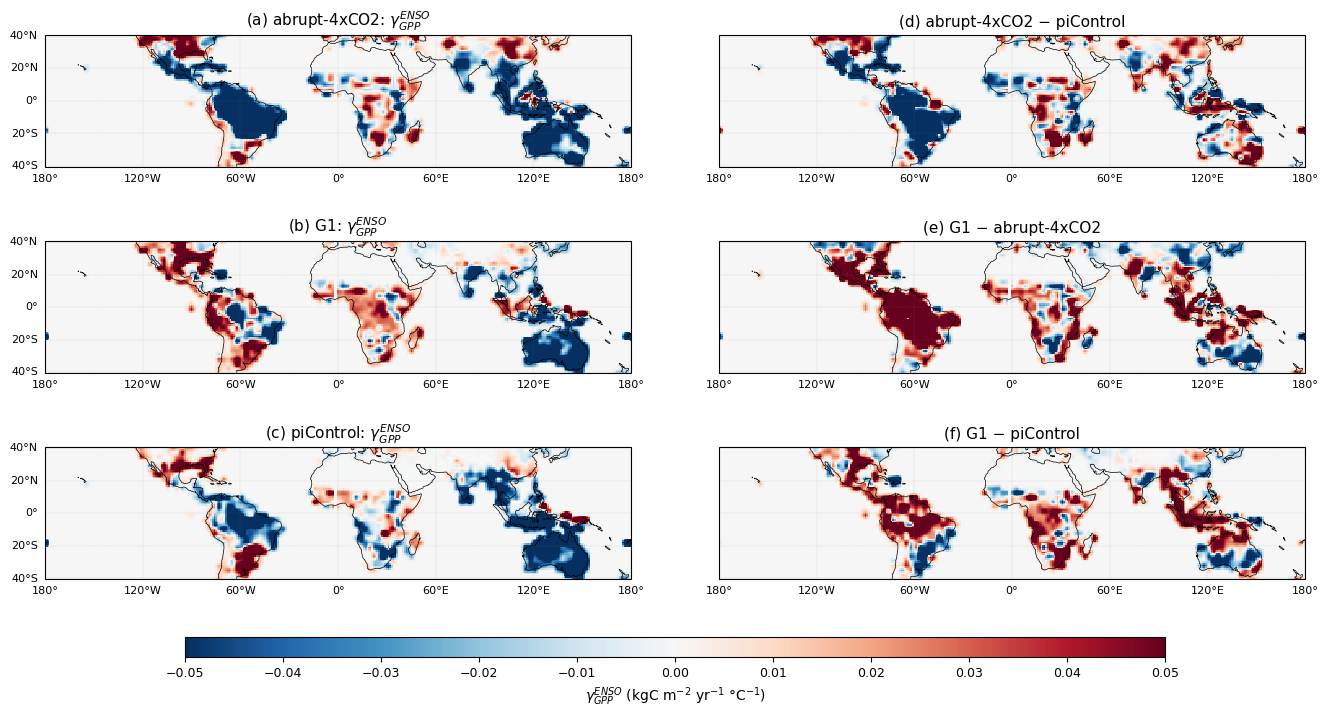

In [79]:
#  Plot spatial distribution maps
fig = plt.figure(figsize=(14, 10))
positions = [
    (0, 0), (1, 0),  # a, d
    (0, 1), (1, 1),  # b, e  
    (0, 2), (1, 2)   # c, f
]

left_data = [beta_maps['abrupt-4xCO2'], beta_maps['G1'], beta_maps['piControl']]
right_data = list(diff_maps.values())

left_titles = [
    r'(a) abrupt-4xCO2: $\gamma_{GPP}^{ENSO}$',
    r'(b) G1: $\gamma_{GPP}^{ENSO}$', 
    r'(c) piControl: $\gamma_{GPP}^{ENSO}$'
]

right_titles = [
    r'(d) abrupt-4xCO2 − piControl',
    r'(e) G1 − abrupt-4xCO2',
    r'(f) G1 − piControl'
]

vmin, vmax = -0.05, 0.05

axes = []
for i in range(3):
    # Left column
    ax_left = plt.subplot(3, 2, i*2 + 1, projection=ccrs.PlateCarree())
    im = ax_left.pcolormesh(
        GPP_annual['abrupt-4xCO2'].lon.values,
        GPP_annual['abrupt-4xCO2'].lat.values,
        left_data[i],
        cmap='RdBu_r', vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    ax_left.coastlines(linewidth=0.5)
    ax_left.set_title(left_titles[i], fontsize=11)
    
    # Add latitude and longitude grid
    gl_left = ax_left.gridlines(draw_labels=True, linewidth=0.2, 
                                color='gray', alpha=0.5, linestyle='--')
    gl_left.top_labels = False
    gl_left.right_labels = False
    gl_left.xlabel_style = {'size': 8}
    gl_left.ylabel_style = {'size': 8}
    
    # Right column
    ax_right = plt.subplot(3, 2, i*2 + 2, projection=ccrs.PlateCarree())
    im = ax_right.pcolormesh(
        GPP_annual['abrupt-4xCO2'].lon.values,
        GPP_annual['abrupt-4xCO2'].lat.values,
        right_data[i],
        cmap='RdBu_r', vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    ax_right.coastlines(linewidth=0.5)
    ax_right.set_title(right_titles[i], fontsize=11)
    
    # Add latitude and longitude grid
    gl_right = ax_right.gridlines(draw_labels=True, linewidth=0.2,
                                  color='gray', alpha=0.5, linestyle='--')
    gl_right.top_labels = False
    gl_right.left_labels = False
    gl_right.right_labels = False
    gl_right.xlabel_style = {'size': 8}
    gl_right.ylabel_style = {'size': 8}

cbar_ax = fig.add_axes([0.15, 0.15, 0.7, 0.02])
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal',
                    ticks=np.arange(-0.05, 0.051, 0.01))
cbar.set_label(r'$\gamma_{GPP}^{ENSO}$ (kgC m$^{-2}$ yr$^{-1}$ °C$^{-1}$)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.subplots_adjust(left=0.05, right=0.95, top=0.80, bottom=0.2,
                    wspace=0.15, hspace=0.1)

plt.savefig('GPP_ENSO_spatial_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

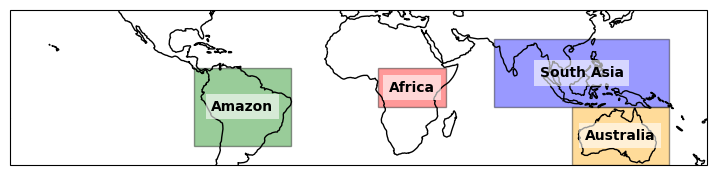

In [100]:
# Four typical geographical regions
regions_demo = {
    'Amazon':     {'lat': (-30, 10),  'lon': (275, 325), 'color': 'green'},   # Amazon rainforest region
    'Africa':     {'lat': (-10, 10), 'lon': (10, 45),   'color': 'red'},      # Equatorial Africa region
    'South Asia':  {'lat': (-10, 25), 'lon': (70, 160),  'color': 'blue'},     # South Asia region
    'Australia':  {'lat': (-40, -10),  'lon': (110, 160), 'color': 'orange'}, # Australian continent
}

fig = plt.figure(figsize=(9, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([1e-3, 359.999, -40, 40], crs=ccrs.PlateCarree())
ax.coastlines()

# plot area
for name, b in regions_demo.items():
    lat1, lat2 = b['lat']
    lon1, lon2 = b['lon']
    rect = Rectangle(
        (lon1, lat1), lon2 - lon1, lat2 - lat1,
        linewidth=1, edgecolor='k', facecolor=b['color'], alpha=0.4,
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)
    ax.text((lon1+lon2)/2, (lat1+lat2)/2, name,
            ha='center', va='center', fontsize=10, weight='bold',
            transform=ccrs.PlateCarree(),
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))


plt.savefig('GPP_ENSO_regions_demo.png', dpi=300, bbox_inches='tight')
plt.show()


**step7.Sensitivity attribution analysis: contributions from temperature and precipitation**

In [ ]:
To understand why GPP sensitivity to ENSO changes under different scenarios, we analyzed the contributions of two key climatic factors: temperature (tas) and precipitation (pr).
Through this attribution analysis, we can better reveal how climate change—via temperature and precipitation—drives variations in terrestrial carbon flux sensitivity, and how geoengineering may mitigate the negative ecological impacts of ENSO events.

In [32]:
#Convert monthly temperature (tas) and precipitation (pr) data to annual mean values (1890–1949)

DATA_DIR = Path(r'D:\cangku\data')

TAS_FILES = {
    'abrupt-4xCO2': 'tas_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1_1890-1949_detrend.nc',
    'G1':           'tas_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc',
}

PR_FILES = {
    'abrupt-4xCO2': 'pr_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1_1890-1949_detrend.nc',
    'G1':           'pr_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend.nc',
}

LAT_SLICE = slice(-40, 40)


def _std_coords(ds):
    if 'latitude' in ds.coords:
        ds = ds.rename({'latitude': 'lat'})
    if 'longitude' in ds.coords:
        ds = ds.rename({'longitude': 'lon'})
    if 'lon' in ds.coords and float(ds['lon'].min()) < 0:
        ds = ds.assign_coords(lon=(ds['lon'] % 360)).sortby('lon')
    return ds

def compute_annual_mean_field(path: Path, varname: str):    #当前代码对降水（pr）也直接取年均，但降水通常需要年累计量
    ds = xr.open_dataset(path)
    ds = _std_coords(ds)

    # identify variable
    if varname not in ds.data_vars:
        varname = list(ds.data_vars)[0]
    da = ds[varname].sel(lat=LAT_SLICE)

    # convert to annual mean
    annual = da.resample(time='YS').mean().sel(time=slice('1890', '1949'))
    annual = annual.astype('float32')

    ds.close()
    return annual


def process_and_save(file_dict, varname):
    for exp, fname in file_dict.items():
        in_path = DATA_DIR / fname
        da_ann = compute_annual_mean_field(in_path, varname)
        out_name = fname.replace('.nc', '_annual_1890-1949.nc')
        out_path = DATA_DIR / out_name
        da_ann.to_netcdf(out_path)
        print(f'[finish] {varname} annual mean saved → {out_path.name}, shape={da_ann.shape}')


if __name__ == '__main__':
    process_and_save(TAS_FILES, 'tas')
    process_and_save(PR_FILES, 'pr')
    print('=== all finished ===')


[finish] tas annual mean saved → tas_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1_1890-1949_detrend_annual_1890-1949.nc, shape=(60, 81, 360)
[finish] tas annual mean saved → tas_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend_annual_1890-1949.nc, shape=(60, 81, 360)
[finish] pr annual mean saved → pr_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1_1890-1949_detrend_annual_1890-1949.nc, shape=(60, 81, 360)
[finish] pr annual mean saved → pr_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend_annual_1890-1949.nc, shape=(60, 81, 360)
=== all finished ===


In [33]:
# Calculate the response coefficients (β) of precipitation and temperature to ENSO, as well as their inter-scenario differences.
#β(variable, ENSO) represents the change in precipitation or temperature per 1σ change in ENSO.

# Directory & file names

DATA_DIR = Path(r'D:\cangku\data')

PR_ANNUAL_FILES = {
    'abrupt-4xCO2': 'pr_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1_1890-1949_detrend_annual_1890-1949.nc',
    'G1':           'pr_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend_annual_1890-1949.nc',
}

TAS_ANNUAL_FILES = {
    'abrupt-4xCO2': 'tas_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1_1890-1949_detrend_annual_1890-1949.nc',
    'G1':           'tas_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend_annual_1890-1949.nc',
}
# Define function to calculate regression coefficient (β)
# x - independent variable (ENSO index) y - dependent variable (climate variable)
def regression_coef(x, y):
    '''simple OLS slope β = cov(x,y)/var(x)'''
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() > 1:
        return np.cov(x[mask], y[mask], ddof=1)[0, 1] / np.var(x[mask], ddof=1)
    return np.nan

# Define fast regression function for full-grid calculation (to improve efficiency)
def grid_regression_quick(var_da, enso_series):
    '''Apply regression at each grid point'''
    arr = var_da.values
    t, nlat, nlon = arr.shape
    betas = np.full((nlat, nlon), np.nan, dtype='float32')
    for i in range(nlat):
        for j in range(nlon):
            y = arr[:, i, j]
            if np.all(np.isnan(y)):
                continue
            betas[i, j] = regression_coef(enso_series, y)
    return betas


# Compute β fields
def compute_sensitivity(var_name, file_dict, enso_indices):
    betas = {}
    for exp, path_name in file_dict.items():
        ds = xr.open_dataset(DATA_DIR / path_name)
        da = ds[var_name].astype('float64')
        # experiment index: 0 for abrupt4xCO2, 1 for G1
        idx = 0 if exp == 'abrupt-4xCO2' else 1
        enso = enso_indices[idx, :]
        betas[exp] = xr.DataArray(
            grid_regression_quick(da, enso),
            coords={'lat': da.lat, 'lon': da.lon},
            dims=('lat', 'lon'),
            name=f'beta_{var_name}_{exp}',
            attrs={
                'description': f'Regression coefficient β({var_name}, ENSO) for {exp}',
                'units': f'{da.attrs.get("units", "")} per σ(ENSO)'
            }
        )
        ds.close()
        print(f'[finish] {var_name}–ENSO regression for {exp}')
    return betas


# ---- compute β(pr) & β(tas) ----
beta_pr = compute_sensitivity('pr', PR_ANNUAL_FILES, ENSO_index)
beta_tas = compute_sensitivity('tas', TAS_ANNUAL_FILES, ENSO_index)


# ---- compute G1 − abrupt4xCO2 differences ----
beta_pr_diff = beta_pr['G1'] - beta_pr['abrupt-4xCO2']
beta_pr_diff.name = 'beta_pr_G1_minus_abrupt4xCO2'
beta_pr_diff.attrs['description'] = 'Difference in pr–ENSO sensitivity (G1 − abrupt-4xCO2)'

beta_tas_diff = beta_tas['G1'] - beta_tas['abrupt-4xCO2']
beta_tas_diff.name = 'beta_tas_G1_minus_abrupt4xCO2'
beta_tas_diff.attrs['description'] = 'Difference in tas–ENSO sensitivity (G1 − abrupt-4xCO2)'


# Save results

out_ds = xr.Dataset(
    {
        'beta_pr_abrupt4xCO2': beta_pr['abrupt-4xCO2'],
        'beta_pr_G1': beta_pr['G1'],
        'beta_pr_diff_G1_minus_abrupt4xCO2': beta_pr_diff,
        'beta_tas_abrupt4xCO2': beta_tas['abrupt-4xCO2'],
        'beta_tas_G1': beta_tas['G1'],
        'beta_tas_diff_G1_minus_abrupt4xCO2': beta_tas_diff,
    },
    attrs={
        'title': 'ENSO sensitivity of pr and tas (1890–1949)',
        'description': 'Regression slope β(variable, ENSO) for abrupt-4xCO2, G1, and their difference',
        'note': 'ENSO index standardized DJF Niño3.4 (60-year, 1890–1949)'
    }
)

out_path = DATA_DIR / 'ENSO_sensitivity_pr_tas_G1_abrupt4xCO2.nc'
out_ds.to_netcdf(out_path)
print(f'[saved] {out_path}')


[finish] pr–ENSO regression for abrupt-4xCO2
[finish] pr–ENSO regression for G1
[finish] tas–ENSO regression for abrupt-4xCO2
[finish] tas–ENSO regression for G1
[saved] D:\cangku\data\ENSO_sensitivity_pr_tas_G1_abrupt4xCO2.nc


* Quantify GPP sensitivity to climate factors (independent effects after controlling for other variables) Partial regression coefficients of GPP with respect to temperature (tas) and precipitation (pr)*

In [34]:
#  ΔGPP = γ_T * Δtas + γ_P * Δpr + ε
#  γ_GPP^T  - temperature sensitivity coefficient (controlling for precipitation effects)
#  γ_GPP^P  - precipitation sensitivity coefficient (controlling for temperature effects)
#  Δγ_GPP^T - difference in γ_T between G1 and abrupt-4xCO2 experiments
#  Δγ_GPP^P - difference in γ_P between G1 and abrupt-4xCO2 experiments
# ====== File paths ======
DATA_DIR = Path(r'D:\cangku\data')

TAS_ANNUAL_FILES = {
    'abrupt-4xCO2': 'tas_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1_1890-1949_detrend_annual_1890-1949.nc',
    'G1':           'tas_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend_annual_1890-1949.nc',
}
PR_ANNUAL_FILES = {
    'abrupt-4xCO2': 'pr_Amon_CanESM5_abrupt-4xCO2_185001-200012_1x1_1890-1949_detrend_annual_1890-1949.nc',
    'G1':           'pr_Amon_CanESM5_G1_r1i1p2f1_gn_185001-194912_1x1_1890-1949_detrend_annual_1890-1949.nc',
}

LAT_SLICE = slice(-40, 40)

# Define partial regression calculation function
def multiple_regression_coeffs(y, x1, x2):

    #  y  - dependent variable (GPP anomalies)
    #  x1 - independent variable 1 (temperature)
    #  x2 - independent variable 2 (precipitation)
    #  Solve using least squares method
    mask = np.isfinite(y) & np.isfinite(x1) & np.isfinite(x2)
    if mask.sum() < 3:
        return np.nan, np.nan
    X = np.stack([x1[mask], x2[mask]], axis=1)
    X = np.column_stack((np.ones(X.shape[0]), X))  # add intercept term
    yv = y[mask]
    beta, _, _, _ = np.linalg.lstsq(X, yv, rcond=None)
    return beta[1], beta[2]  # return γ_GPP^T and γ_GPP^P


#Define fast grid-based partial regression function (to improve efficiency)
def grid_partial_regression(gpp_da, tas_da, pr_da):
    '''Calculate partial regression coefficients γ_GPP^T and γ_GPP^P for each grid cell'''
    gpp = gpp_da.values
    tas = tas_da.values
    pr = pr_da.values
    t, nlat, nlon = gpp.shape

    beta_T = np.full((nlat, nlon), np.nan, dtype='float32')
    beta_P = np.full((nlat, nlon), np.nan, dtype='float32')

    for i in range(nlat):
        for j in range(nlon):
            y = gpp[:, i, j]
            x1 = tas[:, i, j]
            x2 = pr[:, i, j]
            if np.all(np.isnan(y)) or np.all(np.isnan(x1)) or np.all(np.isnan(x2)):
                continue
            bT, bP = multiple_regression_coeffs(y, x1, x2)
            beta_T[i, j] = bT
            beta_P[i, j] = bP
    return beta_T, beta_P

# ========== Main computation==========
results = {}

for exp in ['abrupt-4xCO2', 'G1']:
    # === GPP directly from memory ===
    gpp_da = GPP_annual[exp].sel(lat=LAT_SLICE)
    # ===  tas, pr read from files ===
    ds_tas = xr.open_dataset(DATA_DIR / TAS_ANNUAL_FILES[exp])
    ds_pr  = xr.open_dataset(DATA_DIR / PR_ANNUAL_FILES[exp])
    tas_da = ds_tas['tas'].sel(lat=LAT_SLICE)
    pr_da  = ds_pr['pr'].sel(lat=LAT_SLICE)

    print(f'[start] Computing γ_GPP^T & γ_GPP^P for {exp} ...')
    bT, bP = grid_partial_regression(gpp_da, tas_da, pr_da)

    results[f'gamma_GPP_T_{exp}'] = xr.DataArray(
        bT, coords={'lat': gpp_da.lat, 'lon': gpp_da.lon},
        dims=('lat', 'lon'),
        attrs={'description': f'GPP sensitivity to temperature for {exp}',
               'units': 'kgC m^-2 yr^-1 °C^-1'}
    )
    results[f'gamma_GPP_P_{exp}'] = xr.DataArray(
        bP, coords={'lat': gpp_da.lat, 'lon': gpp_da.lon},
        dims=('lat', 'lon'),
        attrs={'description': f'GPP sensitivity to precipitation for {exp}',
               'units': 'kgC m^-2 yr^-1 (kg m^-2 s^-1)^-1'}
    )

    ds_tas.close(); ds_pr.close()
    print(f'[finish] {exp}: γ_T ({np.nanmin(bT):.3f}, {np.nanmax(bT):.3f}), '
          f'γ_P ({np.nanmin(bP):.3f}, {np.nanmax(bP):.3f})')

#  Differences between G1 and 4xCO2 experiments (Δγ_GPP^T, Δγ_GPP^P)
results['gamma_GPP_T_diff_G1_minus_abrupt4xCO2'] = (
    results['gamma_GPP_T_G1'] - results['gamma_GPP_T_abrupt-4xCO2']
)
results['gamma_GPP_P_diff_G1_minus_abrupt4xCO2'] = (
    results['gamma_GPP_P_G1'] - results['gamma_GPP_P_abrupt-4xCO2']
)

#  Save results
out_ds = xr.Dataset(
    results,
    attrs={
        'title': 'GPP sensitivity to temperature and precipitation (1890–1949)',
        'note': 'γ_GPP^T and γ_GPP^P estimated via multiple regression: GPP = a*T + b*P + ε'
    }
)

out_path = DATA_DIR / 'GPP_TP_partial_sensitivity_G1_abrupt4xCO2.nc'
out_ds.to_netcdf(out_path)
print(f'[saved] {out_path}')


[start] Computing γ_GPP^T & γ_GPP^P for abrupt-4xCO2 ...
[finish] abrupt-4xCO2: γ_T (-0.673, 0.795), γ_P (-63037.961, 59136.113)
[start] Computing γ_GPP^T & γ_GPP^P for G1 ...
[finish] G1: γ_T (-0.822, 0.742), γ_P (-19794.533, 71912.812)
[saved] D:\cangku\data\GPP_TP_partial_sensitivity_G1_abrupt4xCO2.nc


**ENSO–GPP Sensitivity Decomposition  
Display the component breakdown of the GPP response difference (Δγ) to ENSO between the G1 and abrupt-4xCO2 experiments

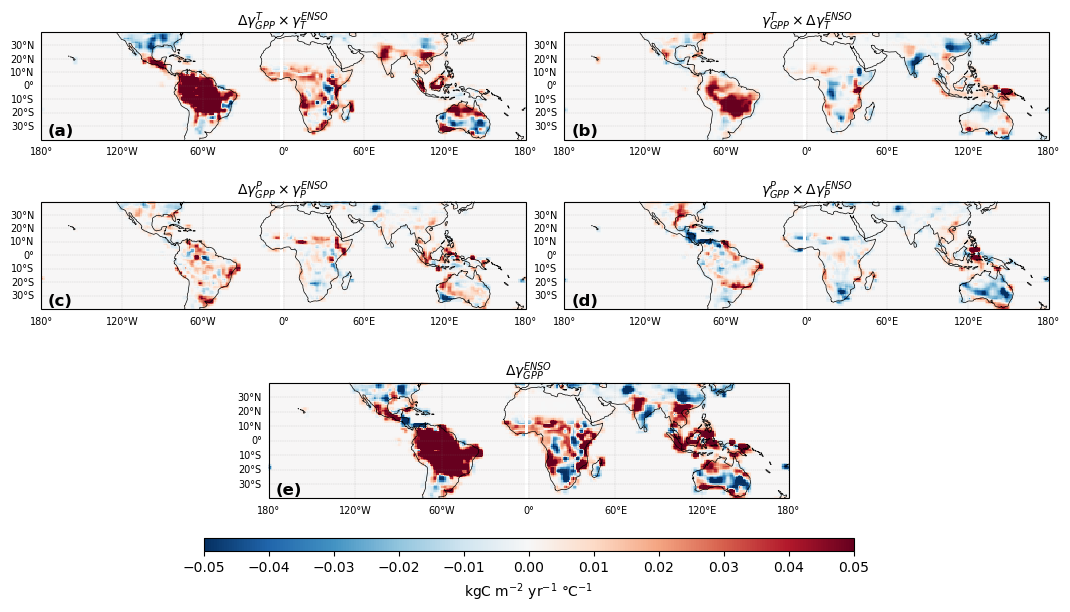

In [89]:

'''
Publication layout version (perfectly aligned)
Decomposition of Δγ_GPP^ENSO (G1 − 4xCO2)
→ (a–d): 2x2 grid
→ (e): centered bottom row, same size as others
→ consistent panel size, extent = 40°S–40°N
'''

#  File paths 
DATA_DIR = r'D:\cangku\data'
file_gpp_tp = f'{DATA_DIR}\\GPP_TP_partial_sensitivity_G1_abrupt4xCO2.nc'
file_enso_tp = f'{DATA_DIR}\\ENSO_sensitivity_pr_tas_G1_abrupt4xCO2.nc'

# read data
ds_gpp = xr.open_dataset(file_gpp_tp)
ds_enso = xr.open_dataset(file_enso_tp)

# Extract variables 
# GPP sensitivity to temperature
γGPP_T_G1  = ds_gpp['gamma_GPP_T_G1']
γGPP_T_4x  = ds_gpp['gamma_GPP_T_abrupt-4xCO2']
ΔγGPP_T    = ds_gpp['gamma_GPP_T_diff_G1_minus_abrupt4xCO2']

# GPP sensitivity to precipitation
γGPP_P_G1  = ds_gpp['gamma_GPP_P_G1']
γGPP_P_4x  = ds_gpp['gamma_GPP_P_abrupt-4xCO2']
ΔγGPP_P    = ds_gpp['gamma_GPP_P_diff_G1_minus_abrupt4xCO2']
# Temperature sensitivity to ENSO
γT_ENSO_G1  = ds_enso['beta_tas_G1']
γT_ENSO_4x  = ds_enso['beta_tas_abrupt4xCO2']
ΔγT_ENSO    = ds_enso['beta_tas_diff_G1_minus_abrupt4xCO2']
# Precipitation sensitivity to ENSO
γP_ENSO_G1  = ds_enso['beta_pr_G1']
γP_ENSO_4x  = ds_enso['beta_pr_abrupt4xCO2']
ΔγP_ENSO    = ds_enso['beta_pr_diff_G1_minus_abrupt4xCO2']

# Sensitivity decomposition calculation 
term_a = ΔγGPP_T * γT_ENSO_4x  # contribution from change in GPP–temperature sensitivity
term_b = γGPP_T_4x * ΔγT_ENSO  # contribution from change in temperature–ENSO sensitivity
term_c = ΔγGPP_P * γP_ENSO_4x  # contribution from change in GPP–precipitation sensitivity
term_d = γGPP_P_4x * ΔγP_ENSO  # contribution from change in precipitation–ENSO sensitivity
term_e = term_a + term_b + term_c + term_d

# Fix longitude seam 
def close_longitude(da):
    lon_vals = da.lon.values
    dlon = np.diff(lon_vals).mean()
    new_lon = np.append(lon_vals, lon_vals[-1] + dlon)
    da_ext = xr.concat([da, da.isel(lon=0)], dim='lon')
    da_ext = da_ext.assign_coords(lon=new_lon)
    return da_ext

# Plotting function
def plot_panel(ax, da, title, letter):
    da_ext = close_longitude(da)
    im = ax.pcolormesh(
        da_ext.lon, da_ext.lat, da_ext,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r', vmin=-0.05, vmax=0.05, shading='auto'
    )
    ax.coastlines(linewidth=0.5)
    ax.set_extent([-180, 180, -40, 40], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=10, pad=2)
    ax.text(-175, -37, f'({letter})', fontsize=12, fontweight='bold')
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size':7}
    gl.ylabel_style = {'size':7}
    return im

# Layout design: precise alignment using GridSpec
fig = plt.figure(figsize=(13, 6.5))
proj = ccrs.PlateCarree()

# GridSpec: three rows and two columns; bottom row centered and same width
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1], width_ratios=[1, 1], figure=fig)
gs.update(wspace=0.08, hspace=0.05)

axes = [
    fig.add_subplot(gs[0, 0], projection=proj),  # (a)
    fig.add_subplot(gs[0, 1], projection=proj),  # (b)
    fig.add_subplot(gs[1, 0], projection=proj),  # (c)
    fig.add_subplot(gs[1, 1], projection=proj),  # (d)
]

# Bottom subplot (e), centered and same width as above
left = 0.30
bottom = 0.08
width = 0.40
height = 0.26
ax_e = fig.add_axes([left, bottom, width, height], projection=proj)
axes.append(ax_e)

# Titles and data
titles = [
    r'$\Delta \gamma_{GPP}^T \times \gamma_T^{ENSO}$',
    r'$\gamma_{GPP}^T \times \Delta \gamma_T^{ENSO}$',
    r'$\Delta \gamma_{GPP}^P \times \gamma_P^{ENSO}$',
    r'$\gamma_{GPP}^P \times \Delta \gamma_P^{ENSO}$',
    r'$\Delta \gamma_{GPP}^{ENSO}$'
]
letters = ['a', 'b', 'c', 'd', 'e']
fields = [term_a, term_b, term_c, term_d, term_e]

for ax, da, t, l in zip(axes, fields, titles, letters):
    im = plot_panel(ax, da, t, l)

# Colorbar
cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.02])
cb = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', ticks=np.arange(-0.05, 0.051, 0.01))
cb.set_label(r'kgC m$^{-2}$ yr$^{-1}$ °C$^{-1}$', fontsize=10)

plt.savefig('Delta_gamma_GPP_ENSO_decomposition_equal_panels.png', dpi=400, bbox_inches='tight')
plt.show()
